# Etapa 2 - Modelagem com Redes neurais

### Foco: Construir, treinar e avaliar um MLP com PytTorch

## 1. Carregamento do dataset e importortação dos pacotes necessários

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

warnings.filterwarnings("ignore")

In [30]:
# Carregando o dataset pré-processado
df = pd.read_csv("data/raw/Telco_customer_churn_preprocessed.csv")
# normaliza nome das colunas para snake_case
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")

# Carregando o dataset original para mapa de geografia
# Resgatando lat. e long. do dataset original
df_original = pd.read_excel("data/raw/Telco_customer_churn.xlsx")
df_original.columns = df_original.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")

geo_features = ['zip_code', 'latitude', 'longitude']

df_mapa_geo = df_original[geo_features].drop_duplicates()

df_final = pd.merge(df, df_mapa_geo, on=geo_features[0], how='left')

# Removendo a coluna zip_code, pois não é mais necessária após a junção
df_final = df_final.drop(columns=[geo_features[0]])

# Normalizando colunas bool (True/False) para int (1/0)
df_final = df_final.astype({col: 'int32' for col in df_final.select_dtypes(include='bool').columns})

# Normalizando as colunas contínuas com StandardScaler
colunas_continuas = ['average_monthly_spend', 'monthly_charges', 'latitude', 'longitude']
scaler = StandardScaler()
df_final[colunas_continuas] = scaler.fit_transform(df_final[colunas_continuas])

print(f"""Dimensão do dataset: 
    - Linhas: {df_final.shape[0]}
    - Colunas: {df_final.shape[1]}
""")


X = df_final.drop("target", axis=1)
y = df_final["target"]

# Ordena features por ordem alfabética
X = X.reindex(sorted(X.columns), axis=1)

num_features = X.shape[1]
print(f"Contagem de features: {num_features}\n")
print("Features: ")
print(df_final.dtypes)



Dimensão do dataset: 
    - Linhas: 7043
    - Colunas: 32

Contagem de features: 31

Features: 
monthly_charges                          float64
target                                     int64
average_monthly_spend                    float64
gender_male                                int32
senior_citizen_yes                         int32
partner_yes                                int32
dependents_yes                             int32
phone_service_yes                          int32
multiple_lines_no_phone_service            int32
multiple_lines_yes                         int32
internet_service_fiber_optic               int32
internet_service_no                        int32
online_security_no_internet_service        int32
online_security_yes                        int32
online_backup_no_internet_service          int32
online_backup_yes                          int32
device_protection_no_internet_service      int32
device_protection_yes                      int32
tech_support_no_inter

## 2. Arquitetura e Treino

### 2.1 Definido arquitetura

In [39]:
# Preparando os Tensores do PyTorch
X_numpy = df_final.drop(columns=['target']).values
y_numpy = df_final['target'].values

# Definição dos hyperparâmetros do modelo
params = {
    "test_size": 0.2,
    "random_state": 42,
    "input_dim": 31,
    "learning_rate": 0.001,
    "epochs": 100,
    "batch_size": 128,
    "threshold": 0.35,
    "patience": 5,
    "hidden_dim1": 64,
    "hidden_dim2": 32,
    "dropout_rate": 0.3,
}

# Dividindo em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_numpy, y_numpy, test_size=params.get("test_size"), stratify=y_numpy, random_state=params.get("random_state")
)

# Convertendo para Tensores do PyTorch (float32 para as features, float32 para o target binário)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1) # Ajusta o shape para (N, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)


# 2. Definindo a Arquitetura da Rede Neural
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim1=64, hidden_dim2=32, dropout_rate=0.3):
        super(NeuralNetwork, self).__init__()
        self.model_type_str = "torch"

        # 1ª Camada Oculta: Aumentamos a dimensionalidade para capturar mais padrões
        self.layer1 = nn.Linear(input_dim, hidden_dim1)
        self.relu1 = nn.ReLU()
        
        # Dropout: Desliga neurônios aleatoriamente no treino para evitar overfitting
        self.dropout1 = nn.Dropout(p=dropout_rate) 

        # 2ª Camada Oculta: Extrai características de mais alto nível
        self.layer2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=dropout_rate)

        # Camada de Saída
        self.layer3 = nn.Linear(hidden_dim2, 1)

    def forward(self, x):
        # Passagem pela primeira camada
        x = self.layer1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        # Passagem pela segunda camada
        x = self.layer2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        # Passagem pela camada de saída
        x = self.layer3(x)

        # ATENÇÃO: O torch.sigmoid(x) foi removido propositalmente!
        # Retornamos os "logits" (valores puros) para maior estabilidade numérica na Loss.
        return x



### 2.2 Loop de treinamento e Avaliação

In [40]:
# Calcula o peso baseando-se na proporção de classes do dataset de treino
num_negativos = (y_train_t == 0).sum().item()
num_positivos = (y_train_t == 1).sum().item()
peso_calculado = num_negativos / (num_positivos + 1e-7) # 1e-7 evita divisão por zero
pos_weight = torch.tensor([peso_calculado], dtype=torch.float32)

print(f"Peso aplicado à classe de Churn (1): {pos_weight.item():.2f}")

# Instanciando o modelo com as 31 features e duas camadas ocultas (64 e 32 neurônios) e dropout de 0.3
model = NeuralNetwork(
    input_dim=params.get("input_dim"),
    hidden_dim1=params.get("hidden_dim1", 64),
    hidden_dim2=params.get("hidden_dim2", 32),
    dropout_rate=params.get("dropout_rate", 0.3)
)

# Criando o DataLoader para gerenciar os batches de treino
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=params.get("batch_size"), shuffle=True)

# Definindo a função de perda e o otimizador
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) # Binary Cross Entropy Loss com logits e peso para a classe positiva
optimizer = optim.Adam(model.parameters(), lr=params.get("learning_rate", 0.01))

# Definindo variáveis para Early Stopping
best_val_loss = float('inf')
patience_counter = 0
best_model_weights = None

print("-" * 80)
print("Iniciando o treinamento no PyTorch...")
print("-" * 80)

for epoch in range(params.get("epochs", 30)):
    epoch_loss = 0.0

    # Loop de Treinamento
    model.train() # Modo de treino
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        
        outputs = model(batch_X)
        batch_y_formatado = batch_y.view(-1, 1).float()
        loss = criterion(outputs, batch_y_formatado)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * batch_X.size(0)
        
    train_loss = epoch_loss / len(train_dataset)
    
    # Loop de Validação
    model.eval() # Modo de avaliação
    with torch.no_grad():
        y_prob_test_t = model(X_test_t)
        y_test_t_formatado = y_test_t.view(-1, 1).float()
        # Calcula o erro (loss) na base de teste para monitorar o desempenho
        val_loss = criterion(y_prob_test_t, y_test_t_formatado).item()

        # Early Stopping (Parada Antecipada)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_weights = model.state_dict() # Salva os pesos do modelo atual como o melhor
        else:
            patience_counter += 1
            if patience_counter >= params.get("patience", 5):
                print(f"\nParada antecipada na época {epoch+1} - Melhor Loss de Teste: {best_val_loss:.4f}\n")
                break

    
    print(f"Época [{epoch+1:02d}/{params.get('epochs', 30)}] - Loss de Treino: {train_loss:.4f} | Loss de Teste: {val_loss:.4f}")

# Carrega os melhores pesos encontrados durante o treinamento de volta no modelo
if best_model_weights is not None:
    model.load_state_dict(best_model_weights)
    print("\nMelhores pesos restaurados no modelo.")

# Loga os hyperparâmetros usados no treinamento
print("\n" + "="*80)
print("Treinamento Concluído!")
print("Hyperparâmetros Utilizados:")
for param, value in params.items():
    print(f"{param:<20}: {value}")
print("="*80)

Peso aplicado à classe de Churn (1): 2.77
--------------------------------------------------------------------------------
Iniciando o treinamento no PyTorch...
--------------------------------------------------------------------------------
Época [01/100] - Loss de Treino: 0.9732 | Loss de Teste: 0.8989
Época [02/100] - Loss de Treino: 0.8363 | Loss de Teste: 0.7952
Época [03/100] - Loss de Treino: 0.7639 | Loss de Teste: 0.7659
Época [04/100] - Loss de Treino: 0.7552 | Loss de Teste: 0.7576
Época [05/100] - Loss de Treino: 0.7427 | Loss de Teste: 0.7541
Época [06/100] - Loss de Treino: 0.7380 | Loss de Teste: 0.7518
Época [07/100] - Loss de Treino: 0.7305 | Loss de Teste: 0.7446
Época [08/100] - Loss de Treino: 0.7220 | Loss de Teste: 0.7452
Época [09/100] - Loss de Treino: 0.7240 | Loss de Teste: 0.7453
Época [10/100] - Loss de Treino: 0.7226 | Loss de Teste: 0.7388
Época [11/100] - Loss de Treino: 0.7142 | Loss de Teste: 0.7420
Época [12/100] - Loss de Treino: 0.7127 | Loss de Test

## 3. Avaliação e Log no MLflow

### 3.1 Avalia os resultados do melhor modelo

In [41]:

model.eval()
with torch.no_grad():
    # Predições finais para métricas de treino
    y_prob_train = model(X_train_t).numpy()
    y_pred_train = (y_prob_train >= params["threshold"]).astype(int)

    # Predições finais para métricas de teste
    y_prob_test = model(X_test_t).numpy()
    y_pred_test = (y_prob_test >= params["threshold"]).astype(int)

metrics = {
    "train_accuracy": accuracy_score(y_train, y_pred_train),
    "test_accuracy": accuracy_score(y_test, y_pred_test),
    "test_f1_score": f1_score(y_test, y_pred_test),
    "test_precision": precision_score(y_test, y_pred_test),
    "test_recall": recall_score(y_test, y_pred_test),
    "test_roc_auc": roc_auc_score(y_test, y_prob_test),
    "train_test_accuracy_gap": accuracy_score(y_train, y_pred_train) - accuracy_score(y_test, y_pred_test)
}

print("-" * 80)
print("Resultados Finais do Modelo (PyTorch):")
print("-" * 80)
for metric, value in metrics.items():
    print(f"{metric:<20}: {value:.4f}")

--------------------------------------------------------------------------------
Resultados Finais do Modelo (PyTorch):
--------------------------------------------------------------------------------
train_accuracy      : 0.7852
test_accuracy       : 0.7573
test_f1_score       : 0.6157
test_precision      : 0.5310
test_recall         : 0.7326
test_roc_auc        : 0.8299
train_test_accuracy_gap: 0.0280


### 3.2 Loga modelo no MLflow

📋 Experiment: 'Modelagem de Rede Neural' | Model: 'nn_baseline' | Run: 'nn_baseline_run'
✅ MLflow configurado para: /Users/dionatasantosdasilva/dev/repos/personal/postech-ml/tech-challenge-fase-1/data/mlflow_tracking/mlruns


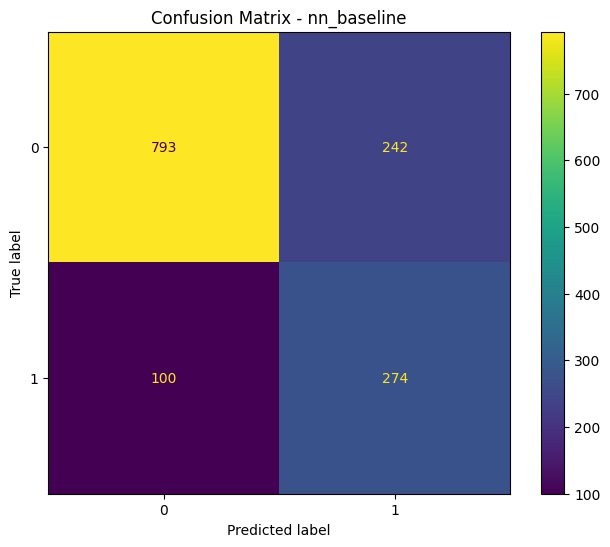

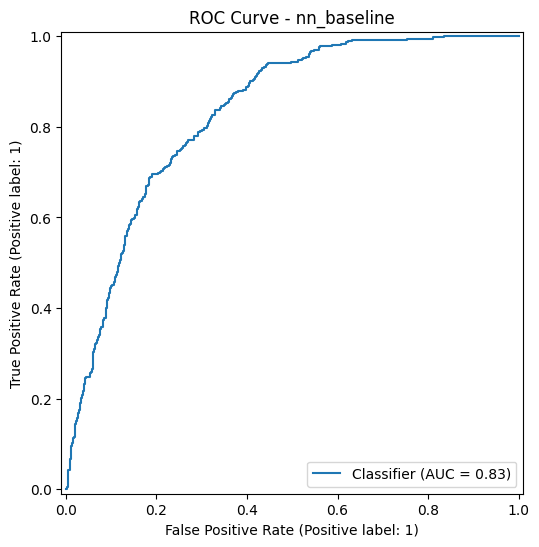

2026/06/01 21:55:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/01 21:55:17 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/dionatasantosdasilva/dev/repos/personal/postech-ml/tech-challenge-fase-1
2026/06/01 21:55:17 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/01 21:55:17 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/dionatasantosdasilva/dev/repos/personal/postech-ml/tech-challenge-fase-1
2026/06/01 21:55:17 INFO mlflow.utils.environment: Detected uv project at /Users/dionatasantosdasilva/dev/repos/personal/postech-ml/te

🚀 [MLflow] Execução registrada com sucesso em 'data/mlflow_tracking'!


In [42]:
import os

# Adicionando raiz do projeto ao caminho
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

from src.utils import mlflow_logger
import importlib
importlib.reload(mlflow_logger)
from src.utils.mlflow_logger import MLflowLogger

# Preparando dicionários de metadados para MLflow
description = "Modelo de Rede Neural com 1 camada oculta para previsão de churn."
tags = {
    "fase": "fase-1",
    "tipo_modelo": "nn-com-2-camada-oculta",
    "framework": "PyTorch",
}
experiment_metadata = {
    "experiment_name": "Modelagem de Rede Neural",
    "experiment_description": description,
    "experiment_tags": tags,
    "run_name": "nn_baseline_run",
    "run_description": description,
    "run_tags": tags,
    "model_name": "nn_baseline",
    "model_description": description,
    "model_tags": tags
}

feature_names = X.columns.tolist()

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)


# Chamando a classe para fazer logging
MLflowLogger.log_run(
    experiment_metadata=experiment_metadata,
    model=model,                        # Modelo Sklearn ou PyTorch
    hyper_params=params,                # Dicionário de hyperparâmetros usados no treinamento
    metrics=metrics,                    # O dicionário de métricas que coletamos
    X_train_df=X_train_df,              # O DataFrame do Pandas com suas 31 colunas
    X_test_df=X_test_df,                # O DataFrame do Pandas com suas 31 colunas
    y_test=y_test,                      # Array do teste
    y_pred_test=y_pred_test,            # Array das predições binárias
    y_prob_test=y_prob_test,            # Array das probabilidades (saída do sigmoid)
)

## 4. Comparativo MLP vs Baseline

In [ ]:
## TODO: Implementar o código para comparar as métricas do MLP com a baseline (no mínimo 4 métricas)

## 5. Análise de Trade-off

In [ ]:
## TODO: Realizar a análise de Trade-off de custo (Falsos positivos vs Falsos Negativos)